In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from helpers.mysql_connections import create_mysql_engine

engine =  create_mysql_engine()



query = 'SELECT * FROM results';
df_results = pd.read_sql( query, engine )
df_results.head(5)

,id,campaign_id,user_id,r_id,email,first_name,last_name,status,ip,latitude,longitude,position,send_date,reported,modified_date
0,1,101,1,AzK6Fg,andresrosales1@corpnet.com,Andres,Rosales,Clicked Link,172.219.4.215,13.678529,-89.248728,Estudiante,2026-03-15 14:07:00,0,2026-03-15 14:15:43
1,2,101,1,MKrJE7,roberto.escobar2@servicios.local,Roberto,Escobar,Email Opened,171.72.253.37,13.765087,-89.130911,Estudiante,2026-03-15 23:33:00,0,2026-03-15 23:40:48
2,3,101,1,itc3EV,andrescortez3@techzone.io,Andres,Cortez,Email Opened,181.252.57.239,13.779004,-89.264338,Estudiante,2026-03-15 20:01:00,0,2026-03-15 20:09:37
3,4,101,1,3hKdJy,adrian.padilla4@campusmail.edu,Adrian,Padilla,Email Opened,187.212.105.99,13.644827,-89.148701,Estudiante,2026-03-15 20:13:00,0,2026-03-15 20:16:33
4,5,101,1,LK9bHL,oscarpadilla5@techzone.io,Oscar,Padilla,Clicked Link,182.6.70.98,13.817546,-89.154148,Estudiante,2026-03-15 21:59:00,0,2026-03-15 22:00:49


In [15]:
q_emails_opened_not_reported = 'SELECT * FROM results WHERE status = "Email Opened" and reported = 0'

q_emails_opened_and_reported = 'SELECT * FROM results WHERE status = "Email Opened" and reported = 1'

## Total of emails

total_emails = len(df_results)

## Number of emails opened and NOT reported

df_emails_opened_not_reported = pd.read_sql( q_emails_opened_not_reported, engine )

emails_opened_not_reported = len(df_emails_opened_not_reported)

## Number of emails opened AND reported

df_emails_opened_and_reported = pd.read_sql( q_emails_opened_and_reported, engine )

emails_opened_and_reported = len(df_emails_opened_and_reported)

## Number of emails opened

emails_opened = emails_opened_not_reported + emails_opened_and_reported

## Metrics of emails opened and NOT reported

emails_opened_not_reported_index = round(emails_opened_not_reported / emails_opened, 3)

emails_opened_not_reported_prtg = round(emails_opened_not_reported / emails_opened * 100,2)

emails_opened_not_reported_dict = {
    'Emails Opened But Not Reported': [emails_opened_not_reported],
    'Index' : [emails_opened_not_reported_index],
    '%': [f'{emails_opened_not_reported_prtg}%']
}

## Metrics of emails opened and AND reported

emails_opened_and_reported_index = round(emails_opened_and_reported / emails_opened, 3)

emails_opened_and_reported_prtg = round(emails_opened_and_reported / emails_opened * 100,2)

emails_opened_and_reported_dict = {
    'Emails Opened And Reported': [emails_opened_and_reported],
    'Index' : [emails_opened_and_reported_index],
    '%': [f'{emails_opened_and_reported_prtg}%']
}


## Metrics of total emails opened

emails_opened_index = round(emails_opened / total_emails, 3)

emails_opened_prtg = round(emails_opened / total_emails * 100,2)


emails_opened_dict = {
    'Emails Opened': [emails_opened],
    'Index' : [emails_opened_index],
    '%': [f'{emails_opened_prtg}%']
}


## DataFrames and Presentation

df_emails_opened_summary = pd.DataFrame( emails_opened_dict, index= ['Values'], columns = ['Emails Opened', 'Index', '%']  )



df_emails_opened_not_reported_summary = pd.DataFrame( emails_opened_not_reported_dict, index= ['Values'], columns = ['Emails Opened But Not Reported', 'Index', '%']  )



df_emails_opened_and_reported_summary = pd.DataFrame( emails_opened_and_reported_dict, index= ['Values'], columns = ['Emails Opened And Reported', 'Index', '%']  )


---

# **Presentacion de la Informacion**

---

In [16]:
display(df_emails_opened_summary)
display(df_emails_opened_not_reported_summary)
display(df_emails_opened_and_reported_summary)

,Emails Opened,Index,%
Values,198,0.396,39.6%


,Emails Opened But Not Reported,Index,%
Values,181,0.914,91.41%


,Emails Opened And Reported,Index,%
Values,17,0.086,8.59%


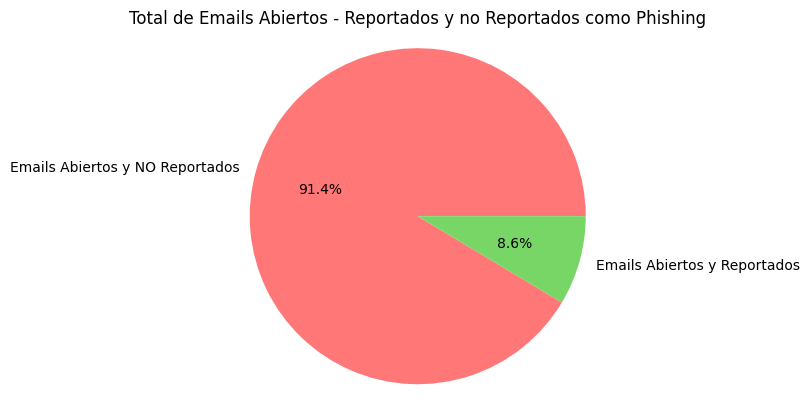

In [17]:
labels = ['Emails Abiertos y NO Reportados', 'Emails Abiertos y Reportados']
values = [emails_opened_not_reported_prtg, emails_opened_and_reported_prtg]
colors = ["#FF7777", "#78D666"]

plt.pie( values, labels=labels, colors=colors,  autopct='%1.1f%%')

plt.title('Total de Emails Abiertos - Reportados y no Reportados como Phishing')
plt.axis('equal')

plt.show()

---

# **Observaciones**

---

Todos los emails en este conjunto de datos estan catalogados como Phishing. Por lo tanto, cualquier interaccion con estos correos es una exposicion directa a la explotacion de una vulnerabilidad dentro de la organizacion.

Cabe mencionar que, los emails evaluados en esta seccion estan catalogados como "Email Opened" o que la unica interaccion del usuario con los emails phishing fue solamente abirlos, no hizo click en ningun URL, no se ingreso informacion en ningun formulario; lo que no supondria un peligro mayor a simple vista. Sin embargo, el haber abierto un correo de este tipo, por si solo, ya representa un peligro inminente; por lo que, teniendo en cuenta que estos correos son ataques de phishing, deberian de ser reportados al momento de ser abiertos y provocar que dicho correo sea bloqueado. Asi que, el no reportar el correo como phishing ya es una omision que pone en riesgo la seguridad de la organizacion.